In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tqdm.autonotebook import tqdm
import pandas as pd
import numpy as np
import os
import shlex
import torch

if torch.cuda.is_available():
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

from torch.utils.data import DataLoader
from BasisConvolution.util.hyperparameters import defaultHyperParameters, parseHyperParameters, finalizeHyperParameters
from BasisConvolution.util.arguments import parser
from BasisConvolution.sph.sphOps import sphOperationStates
from BasisConvolution.util.dataloader import datasetLoader, processFolder#, DataLoader
from BasisConvolution.util.augment import loadAugmentedFrame
from BasisConvolution.util.hyperparameters import make_hash, toPandaDict
from BasisConvolution.util.network import buildModel, runInference

from BasisConvolution.util.augment import loadAugmentedBatch

/tmp/ipykernel_824/3429219320.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


diffSPH not available, will use sphMath for config parsing


In [3]:
hyperParameterDict = defaultHyperParameters()
hyperParameterDict['device'] = 'cuda' if torch.cuda.is_available() else 'cpu'
# hyperParameterDict['device'] = 'cpu'
hyperParameterDict['augmentAngle'] = False
hyperParameterDict['augmentJitter'] = False
hyperParameterDict['maxRollOut'] = 0

In [4]:
datasetPath = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/train'
basisFunction = 'ffourier'
basisTerms = 4
windowFunction = 'None'

architecture = "128 64 32 16" 

# CHANGED: Direct position prediction (like LagrangeBench)
args = parser.parse_args(shlex.split(f'--fluidFeatures "constant:1 attribute:positions attribute:densities" --groundTruth attribute:positions --boundary False --arch "{architecture}" --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 1 --frameDistance 1 --epochs 1 --lossTerms position --lr 5e-2 --outputScaling 1.0'))

hyperParameterDict = parseHyperParameters(args, None)
hyperParameterDict['device'] = 'cuda'
hyperParameterDict['iterations'] = 2**10

train_ds = datasetLoader(processFolder(hyperParameterDict, datasetPath))
print('Dataset has {} samples'.format(len(train_ds)))
print(train_ds.fileFormat)

train_loader = DataLoader(train_ds, shuffle=True, batch_size = hyperParameterDict['batchSize']).batch_sampler
train_iter = iter(train_loader)

finalizeHyperParameters(hyperParameterDict, train_ds)

config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(123, train_ds, hyperParameterDict, unrollLength=1)

Dataset has 12400 samples
newFormat


/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:750: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


In [5]:
database = pd.DataFrame()
models = []
t = None
basisFunctions = ['ffourier']

for basisFunction in basisFunctions:
    for basisTerms in [4]:
        for windowFunction in ['None']:
            # CHANGED: Direct position prediction
            args = parser.parse_args(shlex.split(f'--fluidFeatures "constant:1 attribute:positions attribute:densities" --groundTruth attribute:positions --boundary False --arch "{architecture}" --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 1 --frameDistance 1 --epochs 1 --lossTerms position --lr 5e-2 --outputScaling 1.0'))

            hyperParameterDict = parseHyperParameters(args, None)
            hyperParameterDict['device'] = 'cuda'
            hyperParameterDict['iterations'] = 2**10
            hyperParameterDict['batchSize'] = 8

            train_ds = datasetLoader(processFolder(hyperParameterDict, datasetPath))
            train_loader = DataLoader(train_ds, shuffle=True, batch_size = hyperParameterDict['batchSize']).batch_sampler
            train_iter = iter(train_loader)

            finalizeHyperParameters(hyperParameterDict, train_ds)

            if t is None:
                t = tqdm(range(hyperParameterDict['totalIterations']))
            t.reset( hyperParameterDict['totalIterations'])
            t.set_description(f'{basisFunction} - {basisTerms} - {windowFunction}')

            model, optimizer, scheduler = buildModel(hyperParameterDict, verbose = False)
            model = model.train()

            iterLosses = []
            iterPSNRs = []
            bdatas = []
            
            for i in (range(hyperParameterDict['totalIterations'])):
                try:
                    bdata = next(train_iter)
                except StopIteration:
                    train_iter = iter(train_loader)
                    bdata = next(train_iter)
                bdatas.append(bdata)
                
                configs, attributes, currentStates, priorStates, trajectoryStates = loadAugmentedBatch(bdata, train_ds, hyperParameterDict, unrollLength=1)

                optimizer.zero_grad()
                
                # Network now predicts POSITIONS directly
                predictions = runInference(currentStates, configs, model, verbose = False)
                gts = [traj[0]['fluid']['target'] for traj in trajectoryStates]  # These are now positions!

                # Direct position loss (like LagrangeBench)
                losses = [torch.nn.functional.mse_loss(prediction, gt) for prediction, gt in zip(predictions, gts)]
                loss = torch.stack(losses).mean()
                loss.backward()
                
                psnrs = [20 * torch.log10(gt.abs().max()) - 10 * torch.log10(loss_val) for gt, loss_val in zip(gts, losses)]
                psnr = torch.stack(psnrs).mean()
                
                iterLosses.append([l.item() for l in losses])
                iterPSNRs.append([p.item() for p in psnrs])
                optimizer.step()

                if i % 100 == 0 or i < 10:
                    pred_min = predictions[0].min().item()
                    pred_max = predictions[0].max().item()
                    print(f"[{basisFunction}] Iter {i:4d}: Pred[{pred_min:7.3f}, {pred_max:7.3f}] | PosLoss: {loss.item():.4e}")

                t.set_description(f'{bdata} - {hyperParameterDict["progressLabel"]} - PosLoss: {loss.item():.4e}, PSNR: {psnr.item():.2f}')
                t.update()
                t.refresh()
                
            dataFrame = pd.DataFrame([toPandaDict(hyperParameterDict)] * len(bdatas))
            dataFrame['batches'] = bdatas
            for b in range(len(bdata)):
                dataFrame['losses_{}'.format(b)] = [iterLosses[i][b] for i in range(len(bdatas))]
                dataFrame['psnrs_{}'.format(b)] = [iterPSNRs[i][b] for i in range(len(bdatas))]

            dataFrame['losses'] = [np.mean(iterLosses[i]) for i in range(len(bdatas))]
            dataFrame['psnrs'] = [np.mean(iterPSNRs[i]) for i in range(len(bdatas))]
            dataFrame['iteration'] = np.arange(len(bdatas))

            database = pd.concat([database, dataFrame], ignore_index = True)
            models.append(model)

/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:750: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


  0%|          | 0/1024 [00:00<?, ?it/s]

[ffourier] Iter    0: Pred[ -0.001,   0.001] | PosLoss: 3.3332e-01
[ffourier] Iter    1: Pred[  0.011,   3.148] | PosLoss: 3.5763e-01
[ffourier] Iter    2: Pred[ -0.009,   0.061] | PosLoss: 3.2492e-01
[ffourier] Iter    3: Pred[ -0.005,   0.026] | PosLoss: 3.3194e-01
[ffourier] Iter    4: Pred[ -0.004,   0.031] | PosLoss: 3.3204e-01
[ffourier] Iter    5: Pred[ -0.036,   0.207] | PosLoss: 3.2829e-01
[ffourier] Iter    6: Pred[ -0.160,   0.740] | PosLoss: 3.1650e-01
[ffourier] Iter    7: Pred[ -0.428,   2.365] | PosLoss: 2.9171e-01
[ffourier] Iter    8: Pred[ -0.165,   3.001] | PosLoss: 3.1018e-01
[ffourier] Iter    9: Pred[ -0.039,   2.152] | PosLoss: 2.4899e-01
[ffourier] Iter  100: Pred[ -0.103,   1.450] | PosLoss: 2.0981e-02
[ffourier] Iter  200: Pred[ -0.025,   1.119] | PosLoss: 3.5119e-03
[ffourier] Iter  300: Pred[ -0.101,   1.416] | PosLoss: 1.6508e-03
[ffourier] Iter  400: Pred[ -0.277,   1.283] | PosLoss: 1.5456e-03
[ffourier] Iter  500: Pred[ -0.016,   1.155] | PosLoss: 1.2333

In [6]:
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np

from BasisConvolution.util.augment import loadAugmentedFrame
from BasisConvolution.util.network import runInference

In [7]:
basisTerms = database['basisTerms'].unique()
basisFunctions = database['basisFunctions'].unique()

print(basisTerms)
print(basisFunctions)

hues = sns.color_palette(n_colors = len(basisFunctions))
linestyles = ['--', '-', ':', '-.']

[4]
['ffourier']


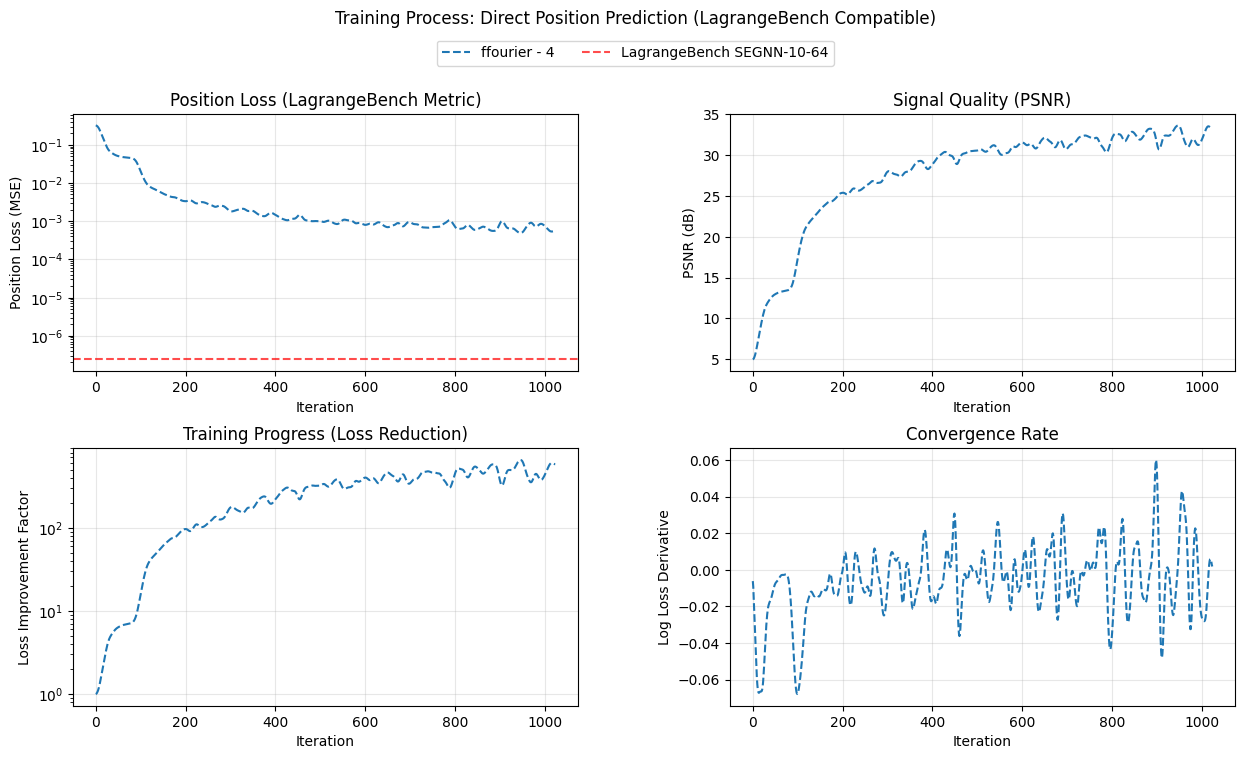

In [8]:
# Updated plotting cell (fixed for position-only prediction)
fig, axis = plt.subplots(2, 2, figsize = (15, 8), sharey = False, squeeze= False)

for i, basisFunction in enumerate(basisFunctions):
    for j, basisTerm in enumerate(basisTerms):
        subDatabase = database[(database['basisFunctions'] == basisFunction) & (database['basisTerms'] == basisTerm)]

        iters = subDatabase['iteration']
        losses = subDatabase['losses']  # These are now position losses
        psnrs = subDatabase['psnrs']

        # Smooth the curves
        losses = gaussian_filter1d(losses, sigma = 5)
        psnrs = gaussian_filter1d(psnrs, sigma = 5)

        # Plot position losses (top left) - Main metric
        axis[0,0].plot(iters, losses, label = f'{basisFunction} - {basisTerm}', color = hues[i], ls = linestyles[j])
        
        # Plot PSNR (top right)
        axis[0,1].plot(iters, psnrs, label = f'{basisFunction} - {basisTerm}', color = hues[i], ls = linestyles[j])
        
        # Plot loss improvement (bottom left) - relative to start
        if len(losses) > 0:
            initial_loss = losses[0] if not np.isnan(losses[0]) else losses[1]
            improvement = initial_loss / losses
            axis[1,0].plot(iters, improvement, label = f'{basisFunction} - {basisTerm}', color = hues[i], ls = linestyles[j])
        
        # Plot convergence rate (bottom right) - loss derivative
        if len(losses) > 10:
            convergence_rate = np.gradient(np.log(losses + 1e-10))  # Log derivative
            axis[1,1].plot(iters, convergence_rate, label = f'{basisFunction} - {basisTerm}', color = hues[i], ls = linestyles[j])

# Configure position loss plot (top left) - Main comparison
axis[0,0].set_yscale('log')
axis[0,0].set_xlabel('Iteration')
axis[0,0].set_ylabel('Position Loss (MSE)')
axis[0,0].set_title('Position Loss (LagrangeBench Metric)')
axis[0,0].grid(True, alpha=0.3)

# Add LagrangeBench reference line
lagrangebench_mse5 = 2.4e-7  # SEGNN-10-64 result for 2D TGV
axis[0,0].axhline(y=lagrangebench_mse5, color='red', linestyle='--', alpha=0.7, label='LagrangeBench SEGNN-10-64')

# Configure PSNR plot (top right)
axis[0,1].set_xlabel('Iteration')
axis[0,1].set_ylabel('PSNR (dB)')
axis[0,1].set_title('Signal Quality (PSNR)')
axis[0,1].grid(True, alpha=0.3)

# Configure improvement plot (bottom left)
axis[1,0].set_xlabel('Iteration')
axis[1,0].set_ylabel('Loss Improvement Factor')
axis[1,0].set_title('Training Progress (Loss Reduction)')
axis[1,0].grid(True, alpha=0.3)
axis[1,0].set_yscale('log')

# Configure convergence rate plot (bottom right)
axis[1,1].set_xlabel('Iteration')
axis[1,1].set_ylabel('Log Loss Derivative')
axis[1,1].set_title('Convergence Rate')
axis[1,1].grid(True, alpha=0.3)

# Add legend
handles, labels = axis[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol = 5, bbox_to_anchor=(0.5, 0.95))

# Add overall title and adjust layout
fig.suptitle('Training Process: Direct Position Prediction (LagrangeBench Compatible)', y=0.98)
fig.subplots_adjust(top=0.85, hspace=0.3, wspace=0.3)


props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)


plt.show()

In [9]:
if len(models) > 0:
    # Save all trained models, using their basis function names if available
    # If basisFunctions is not defined, use generic names
    if 'basisFunctions' in locals():
        basis_names = list(basisFunctions)
    else:
        basis_names = [f'basis_{i}' for i in range(len(models))]
    models_dict_temp = {basis_name: model for basis_name, model in zip(basis_names, models)}

In [10]:
if len(models) > 0:
    # Save all trained models, using their basis function names if available
    # If basisFunctions is not defined, use generic names
    if 'basisFunctions' in locals():
        basis_names = list(basisFunctions)
    else:
        basis_names = [f'basis_{i}' for i in range(len(models))]
    models_dict = {basis_name: model for basis_name, model in zip(basis_names, models)}

from model_utils import save_model
import torch
import os

basisTerms = 4
windowFunction = 'None'
datasetPath = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/train'

save_dir = "/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/position/128_64_32_16"
os.makedirs(save_dir, exist_ok=True)

for basis_name, model in models_dict.items():
    # Use basis_name instead of basisFunction, and explicitly define the other variables
    args_save = parser.parse_args(shlex.split(f'--fluidFeatures "constant:1 attribute:positions attribute:densities" --groundTruth attribute:positions --boundary False --arch "{architecture}" --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 1 --frameDistance 1 --epochs 1 --lossTerms position --lr 5e-2 --outputScaling 1.0'))

    model_hyperparams = parseHyperParameters(args_save, None)
    model_hyperparams['device'] = 'cuda'
    model_hyperparams['iterations'] = 2**10
    model_hyperparams['batchSize'] = 8
    train_ds_save = datasetLoader(processFolder(model_hyperparams, datasetPath))
    finalizeHyperParameters(model_hyperparams, train_ds_save)
    
    torch.save({
        'model_state_dict': model.state_dict(),
        'basis_function': basis_name,
        'hyperparameters': model_hyperparams
    }, f"{save_dir}/{basis_name}_model.pth")

/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:750: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


In [12]:
import torch
import os
from BasisConvolution.util.network import buildModel

save_dir = "/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/position/64_16_4_4"

models_dict = {}
hyperParameterDict = None

for basis_name in ['ffourier']:
    model_path = f"{save_dir}/{basis_name}_model.pth"
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location='cuda', weights_only=False)
        model_hyperparams = checkpoint['hyperparameters']
        model_hyperparams['device'] = 'cuda'
        
        model, _, _ = buildModel(model_hyperparams, verbose=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        
        models_dict[basis_name] = model
        
        if hyperParameterDict is None:
            hyperParameterDict = model_hyperparams

In [ ]:
test_datasetPath = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/test'
test_ds = datasetLoader(processFolder(hyperParameterDict, test_datasetPath))
finalizeHyperParameters(hyperParameterDict, test_ds)

sample_idx = 0
config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(sample_idx, test_ds, hyperParameterDict)

if 'fluid' in currentState:
    fluid_positions = currentState['fluid']['positions']
    num_particles = fluid_positions.shape[0]
    spatial_dims = fluid_positions.shape[1]
    print(f'Number of particles per trajectory: {num_particles:,}')
    print(f'Spatial dimensions: {spatial_dims}D')

import os
import h5py

test_files = [f for f in os.listdir(test_datasetPath) if f.endswith('.hdf5')]
sample_file = os.path.join(test_datasetPath, test_files[0])

with h5py.File(sample_file, 'r') as f:
    if 'simulationExport' in f:
        timestep_groups = [key for key in f['simulationExport'].keys() if key.isdigit()]
        frames_per_trajectory = len(timestep_groups)

total_trajectories = len(test_files)
total_frames_combined = len(test_ds)

print(f'Test trajectories: {total_trajectories}')
print(f'Frames per trajectory: {frames_per_trajectory}')
print(f'Total frames in combined dataset: {total_frames_combined:,}')

import random
random_trajectory_idx = random.randint(0, total_trajectories - 1)
print(f'Selected test trajectory #{random_trajectory_idx}')

finalizeHyperParameters(hyperParameterDict, test_ds)

Unroll length  1  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Number of particles per trajectory: 2,500
Spatial dimensions: 2D
Test trajectories: 50
Frames per trajectory: 126
Total frames in combined dataset: 6,300
Selected test trajectory #40
Unroll length  1  exceeds maximum, limiting to 0


{'coordinateMapping': 'cartesian',
 'windowFunction': 'None',
 'liLoss': 'yes',
 'initialLR': 0.01,
 'finalLR': 0.0001,
 'lrStep': 10,
 'epochs': 1,
 'frameDistance': 0,
 'iterations': 1024,
 'dataDistance': 1,
 'cutoff': 1800,
 'dataLimit': -1,
 'seed': 42,
 'minUnroll': 2,
 'maxUnroll': 0,
 'historyLength': 0,
 'augmentAngle': False,
 'augmentJitter': False,
 'jitterAmount': 0.1,
 'networkSeed': 42,
 'network': 'default',
 'normalized': False,
 'adjustForFrameDistance': True,
 'weight_decay': 0,
 'input': './',
 'output': 'training',
 'loss': 'mse',
 'batchSize': 8,
 'fluidFeatures': 'constant:1',
 'boundaryFeatures': 'False',
 'boundary': False,
 'groundTruth': 'dt@attribute:positions',
 'gtMode': 'abs',
 'verbose': False,
 'independent_dxdt': False,
 'unrollIncrement': 100,
 'networkType': 'w/o shift',
 'normalization': 'none',
 'skipLastShift': False,
 'shiftLoss': False,
 'activation': 'silu',
 'dataIndex': '',
 'dxdtLossScaling': 2,
 'exportPath': 'experiments',
 'arch': '128 64

In [ ]:
from plotting_utils import *
frames_to_plot = [1, 30, 50, 100, 125]
figsize = (12, 12)
frame_idx = 15

 
print(f"Available models: {list(models_dict.keys())}")
print(f"Plotting frames: {frames_to_plot}")

Available models: ['ffourier', 'linear', 'chebyshev']
Plotting frames: [1, 30, 50, 100, 125]


Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0


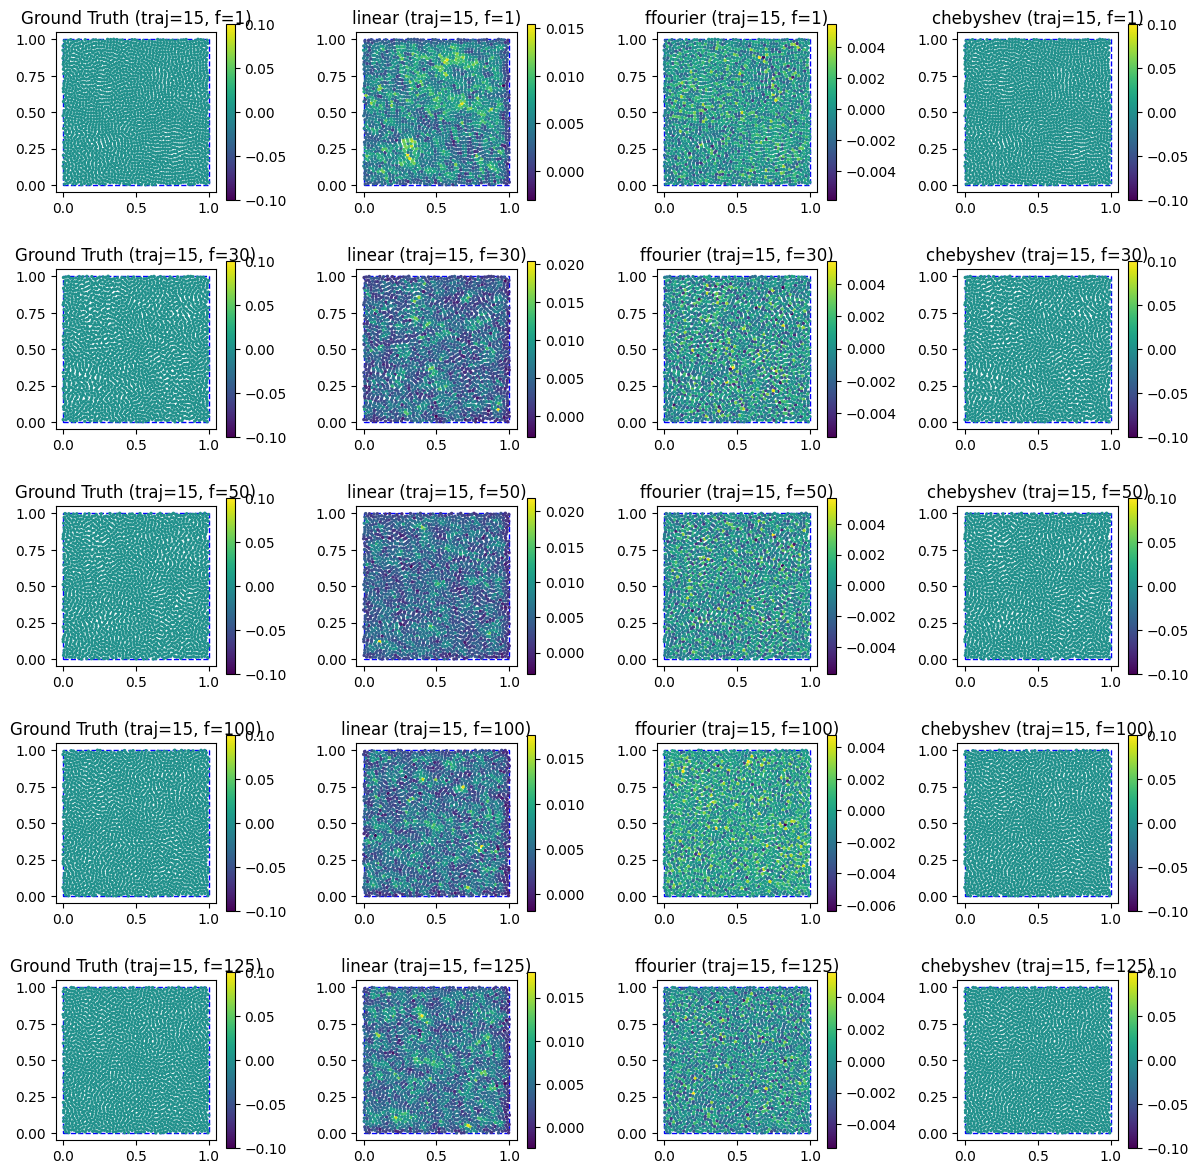

In [ ]:
visualize_density_comparison_sph(models_dict=models_dict,
    ds=test_ds,
    hyperParameterDict=hyperParameterDict,
    frames=frames_to_plot,
    trajectory_index=frame_idx,
    figsize=figsize,
    frames_per_trajectory=126
)

Unroll length  8  exceeds maximum, limiting to 0
Error creating ground truth flow: index -1 is out of bounds for axis 0 with size 0
Error creating ffourier flow: index -1 is out of bounds for axis 0 with size 0
Error creating chebyshev flow: index -1 is out of bounds for axis 0 with size 0
Unroll length  8  exceeds maximum, limiting to 0
Error creating ground truth flow: index -1 is out of bounds for axis 0 with size 0
Error creating chebyshev flow: index -1 is out of bounds for axis 0 with size 0
Unroll length  8  exceeds maximum, limiting to 0
Error creating ground truth flow: index -1 is out of bounds for axis 0 with size 0
Error creating chebyshev flow: index -1 is out of bounds for axis 0 with size 0
Unroll length  8  exceeds maximum, limiting to 0
Error creating ground truth flow: index -1 is out of bounds for axis 0 with size 0
Error creating chebyshev flow: index -1 is out of bounds for axis 0 with size 0
Unroll length  8  exceeds maximum, limiting to 0
Error creating ground tr

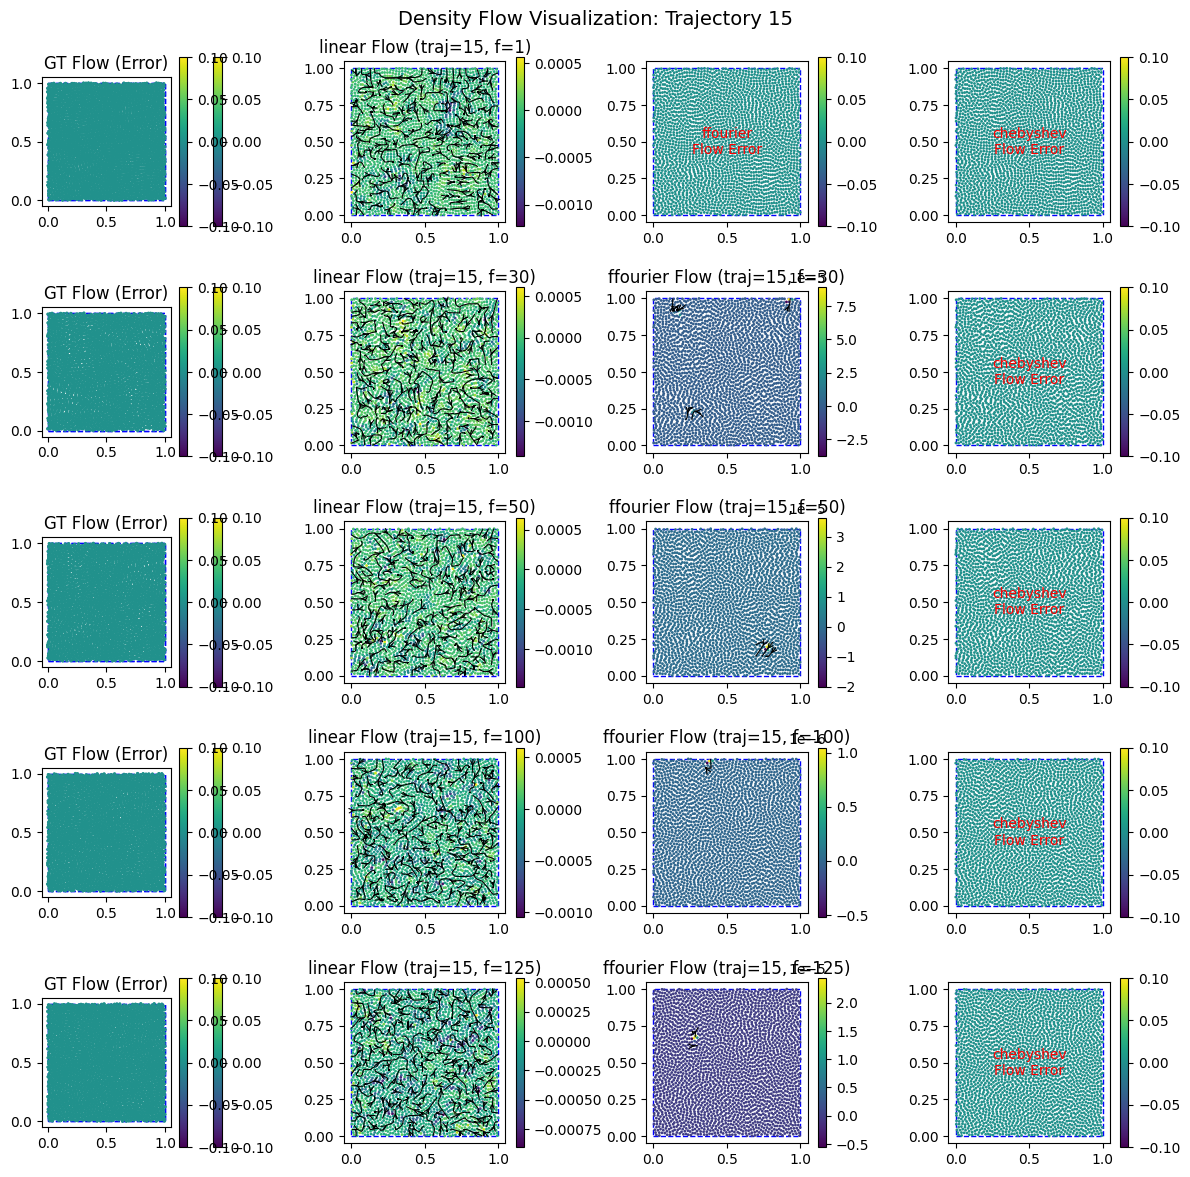

In [ ]:
visualize_flow_comparison_sph(models_dict=models_dict,
    ds=test_ds,
    hyperParameterDict=hyperParameterDict,
    frames=frames_to_plot,
    trajectory_index=frame_idx,
    figsize=figsize
)